# Preparación del análisis del balance de materia en fabricación de queso mediante `Python`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [77]:
import seaborn as sns
sns.set_style("whitegrid")

In [78]:
url_datos = 'https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm.csv'

try:
    df = pd.read_csv(url_datos, decimal = ",", sep=';', encoding='ISO-8859-1')
    print("¡Archivo ", url_datos," cargado correctamente!")
    print(f"Dimensiones de los datos: {df.shape}")
except Exception as e:
    print(f"Error al cargar el archivo: {e}")

¡Archivo  https://raw.githubusercontent.com/juanriera/master-queseria/master/datos/fab_queso_bm.csv  cargado correctamente!
Dimensiones de los datos: (448, 19)


In [79]:
# Bloque 1/5: Inicialización, Carga y Limpieza

# Asegurar que el orden de las columnas no se modifica
columnas_iniciales = df.columns.tolist()

# Asegurar que las columnas de entrada sean numéricas
columnas_numericas_entrada = [
    'litros_past', 'mg_cuba', 'mp_cuba', 'lactosa_cuba', 
    'est_salida_salmuera', 'mg_salida_salmuera'
]
for col in columnas_numericas_entrada:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Manejo y conversión explícita de la columna 'fecha'
if 'fecha' in df.columns:
    # 1. Convertir 'fecha' a tipo datetime (formato D/M/A)
    df['fecha'] = pd.to_datetime(
        df['fecha'], 
        format='%d/%m/%Y',
        errors='coerce' 
    )
    
    # 2. CREACIÓN DEL ÍNDICE 'fecha_index' (Corregido: Sin inplace=True)
    
    # Primero, establecemos el índice y reasignamos el DF
    df = df.set_index('fecha', drop=False) # <--- Aquí la corrección: Sin inplace=True
    
    # Luego, renombramos el índice
    df.index.name = 'fecha_index'
    
    print("   ✅ Columna 'fecha' convertida y índice 'fecha_index' creado.")
else:
    print("   ⚠️ ADVERTENCIA: La columna 'fecha' no existe. Imposible crear 'fecha_index'.")

   ✅ Columna 'fecha' convertida y índice 'fecha_index' creado.


In [80]:
# --- 2. CÁLCULO DE ENTRADAS BRUTAS (INTERMEDIOS) ---
df['est_cuba'] = df['mg_cuba'] + df['mp_cuba'] + df['lactosa_cuba'] 
df['est_kg_entrada'] = df['litros_past'] * df['est_cuba'] / 100 
df['mg_kg_entrada'] = df['litros_past'] * df['mg_cuba'] / 100 
# No necesitamos esm_kg_entrada ni esm_kg_salida aquí.

# 🚨 VERIFICACIÓN: Nos aseguramos de que 'peso_queso_total' exista en el df original.
if 'peso_queso_total' not in df.columns:
    print("   ❌ ERROR: La columna 'peso_queso_total' es requerida para la conversión analítica y no existe.")
    # Si no existe, usamos una aproximación por defecto para no romper el flujo
    df['peso_queso_total'] = df['litros_past'] * 0.1 
    print("   ⚠️ ADVERTENCIA: Usando aproximación (litros_past * 0.1) como 'peso_queso_total'.")
else:
    print("   ✅ Usando columna original 'peso_queso_total'.")


# --- 3. SIMULACIÓN DE RENDIMIENTO (Pérdidas ajustadas) ---

# Diccionario fijo para coef_recup_mp (91% a 98%)
coef_recup_mp = {
    'IQM pequeño': 0.891,
    'Oveja DO 3 kg': 0.894,
    'Tierno 3 kg': 0.897,
    'Oveja DO pequeño': 0.900,
    'Madurado pequeño': 0.903,
    'Wasabi 3 kg': 0.906,
    'Cabra Barra 4,2 kg': 0.909,
    'Light Barra 4,2 kg': 0.912,
    'Light 3 kg': 0.915,
    'Tierno Barra 4,2 kg': 0.918,
    'Madurado 3 kg': 0.921,
    'IQM+ Barra 4,2 kg': 0.924,
    'Wasabi Barra 4,2 kg': 0.927,
    'Oveja DO Barra 4,2 kg': 0.930,
    'Tierno Barra 3 kg': 0.933,
    'IQM Barra 3 kg': 0.936,
    'Tierno mini': 0.939,
    'Light mini': 0.942,
    'Cabra mini': 0.945,
    'IQM mini': 0.948,
    'Wasabi mini': 0.951,
    'Oveja normal 3 kg': 0.954,
    'IQM sin lactosa': 0.957,
    'Madurado Barra 4,2 kg': 0.960,
    'Tierno pequeño': 0.963,
    'Vaca Barra 4,2 kg': 0.969,
    'IQM+ 3 kg': 0.972,
    'Madurado mini': 0.975,
    'Oveja normal Barra 4,2 kg': 0.978,
    'Wasabi pequeño': 0.981,
}


# Diccionario fijo para coef_recup_mg (89% a 96%)
coef_recup_mg = {
    'IQM pequeño': 0.891,
    'Oveja DO 3 kg': 0.894,
    'Tierno 3 kg': 0.897,
    'Oveja DO pequeño': 0.900,
    'Madurado pequeño': 0.903,
    'Wasabi 3 kg': 0.906,
    'Cabra Barra 4,2 kg': 0.909,
    'Light Barra 4,2 kg': 0.912,
    'Light 3 kg': 0.915,
    'Tierno Barra 4,2 kg': 0.918,
    'Madurado 3 kg': 0.921,
    'IQM+ Barra 4,2 kg': 0.924,
    'Wasabi Barra 4,2 kg': 0.927,
    'Oveja DO Barra 4,2 kg': 0.930,
    'Tierno Barra 3 kg': 0.933,
    'IQM Barra 3 kg': 0.936,
    'Tierno mini': 0.939,
    'Light mini': 0.942,
    'Cabra mini': 0.945,
    'IQM mini': 0.948,
    'Wasabi mini': 0.951,
    'Oveja normal 3 kg': 0.954,
    'IQM sin lactosa': 0.957,
    'Madurado Barra 4,2 kg': 0.960,
    'Tierno pequeño': 0.963,
    'Vaca Barra 4,2 kg': 0.969,
    'IQM+ 3 kg': 0.972,
    'Madurado mini': 0.975,
    'Oveja normal Barra 4,2 kg': 0.978,
    'Wasabi pequeño': 0.981,
}


std_recup_mp = {
    'IQM pequeño': 0.0004,
    'Oveja DO 3 kg': 0.0004,
    'Tierno 3 kg': 0.0004,
    'Oveja DO pequeño': 0.0004,
    'Madurado pequeño': 0.0005,
    'Wasabi 3 kg': 0.0005,
    'Cabra Barra 4,2 kg': 0.0005,
    'Light Barra 4,2 kg': 0.0005,
    'Light 3 kg': 0.0005,
    'Tierno Barra 4,2 kg': 0.0006,
    'Madurado 3 kg': 0.0006,
    'IQM+ Barra 4,2 kg': 0.0006,
    'Wasabi Barra 4,2 kg': 0.0006,
    'Oveja DO Barra 4,2 kg': 0.0006,
    'Tierno Barra 3 kg': 0.0007,
    'IQM Barra 3 kg': 0.0007,
    'Tierno mini': 0.0007,
    'Light mini': 0.0007,
    'Cabra mini': 0.0008,
    'IQM mini': 0.0008,
    'Wasabi mini': 0.0008,
    'Oveja normal 3 kg': 0.0008,
    'IQM sin lactosa': 0.0009,
    'Madurado Barra 4,2 kg': 0.0009,
    'Tierno pequeño': 0.0009,
    'Vaca Barra 4,2 kg': 0.0009,
    'IQM+ 3 kg': 0.0010,
    'Madurado mini': 0.0010,
    'Oveja normal Barra 4,2 kg': 0.0010,
    'Wasabi pequeño': 0.0010,
}
std_recup_mg = {
    'IQM pequeño': 0.0005,
    'Oveja DO 3 kg': 0.0005,
    'Tierno 3 kg': 0.0005,
    'Oveja DO pequeño': 0.0005,
    'Madurado pequeño': 0.0006,
    'Wasabi 3 kg': 0.0006,
    'Cabra Barra 4,2 kg': 0.0006,
    'Light Barra 4,2 kg': 0.0006,
    'Light 3 kg': 0.0006,
    'Tierno Barra 4,2 kg': 0.0007,
    'Madurado 3 kg': 0.0007,
    'IQM+ Barra 4,2 kg': 0.0007,
    'Wasabi Barra 4,2 kg': 0.0007,
    'Oveja DO Barra 4,2 kg': 0.0007,
    'Tierno Barra 3 kg': 0.0008,
    'IQM Barra 3 kg': 0.0008,
    'Tierno mini': 0.0008,
    'Light mini': 0.0008,
    'Cabra mini': 0.0009,
    'IQM mini': 0.0009,
    'Wasabi mini': 0.0009,
    'Oveja normal 3 kg': 0.0009,
    'IQM sin lactosa': 0.0010,
    'Madurado Barra 4,2 kg': 0.0010,
    'Tierno pequeño': 0.0010,
    'Vaca Barra 4,2 kg': 0.0010,
    'IQM+ 3 kg': 0.0011,
    'Madurado mini': 0.0011,
    'Oveja normal Barra 4,2 kg': 0.0011,
    'Wasabi pequeño': 0.0011,
}

# Limpieza rigurosa de la columna 'receta' antes de mapear
df['receta'] = df['receta'].astype(str).str.strip().str.lower()
coef_recup_mp = {k.strip().lower(): v for k, v in coef_recup_mp.items()}
coef_recup_mg = {k.strip().lower(): v for k, v in coef_recup_mg.items()}
std_recup_mp = {k.strip().lower(): v for k, v in std_recup_mp.items()}
std_recup_mg = {k.strip().lower(): v for k, v in std_recup_mg.items()}

df['coef_recup_mp'] = np.random.normal(
    loc=df['receta'].map(coef_recup_mp),
    scale=df['receta'].map(std_recup_mp)
)

df['coef_recup_mg'] = np.random.normal(
    loc=df['receta'].map(coef_recup_mg),
    scale=df['receta'].map(std_recup_mg)
)

# Kilos recuperados de materia prima (MP)
df['mp_kg_recuperado'] = df['kg_cuba'] * df['mp_cuba'] / 100 * df['coef_recup_mp']

# Kilos recuperados de materia grasa (MG)
df['mg_kg_recuperado'] = df['kg_cuba'] * df['mg_cuba'] / 100 * df['coef_recup_mg']

# Kilos recuperados de extracto seco (EST)
df['est_kg_recuperado'] = df['mp_kg_recuperado'] + df['kg_cuba'] * df['lactosa_cuba'] / 100 * 0.20

# Porcentaje de MG y EST en el queso (por fila)
# Ejemplo: df['mg_queso'] = 28.5 significa 28.5% MG en el queso
df['kg_queso_por_mg'] = df['mg_kg_recuperado'] / (df['mg_salida_salmuera'] / 100)
df['kg_queso_por_est'] = df['est_kg_recuperado'] / (df['est_salida_salmuera'] / 100)

# Peso del queso estimado usando el EST analizado (ya incluye sal)
df['kg_queso_estimado'] = df['est_kg_recuperado'] / (df['est_salida_salmuera'] / 100)

ajuste_formato_media = {'500 g': -0.012, '1 kg': -0.008, '3 kg': 0.005, 'barra': 0.003}
ajuste_formato_std = {'500 g': -0.018, '1 kg': -0.010, '3 kg': 0.003, 'barra': 0.002}

print("   ✅ Valores 'Analíticos Estimados' (concentración) generados.")



   ✅ Usando columna original 'peso_queso_total'.
   ✅ Valores 'Analíticos Estimados' (concentración) generados.


In [81]:

# --- 5. EXPORTACIÓN DEL ARCHIVO INTERMEDIO (Originales + Analíticos Estimados) ---
nombre_archivo_intermedio = 'datos_analiticos_simulados.csv'

# Reordenar columnas - cambiamos est_cuba al principio
columna_objetivo = 'est_cuba'

# 1. Detectar columnas nuevas ANTES de reordenar
columnas_nuevas = [col for col in df.columns if col not in columnas_iniciales]

# 2. Insertar 'est_cuba' en la posición deseada dentro de columnas_iniciales
if columna_objetivo in columnas_nuevas:
    columnas_nuevas.remove(columna_objetivo)
    columnas_iniciales.insert(4, columna_objetivo)

# 3. Reordenar el DataFrame con columnas originales + nuevas
df = df[columnas_iniciales + columnas_nuevas]

# 4. Eimino columnas no necesarias, porque ya se han hecho los cálculos
# columnas_a_eliminar = [
#     'est_kg_entrada',
#     'mg_kg_entrada',
#     'mu_final',
#     'sigma_final',
#     'factor_rendimiento_est',
#     'factor_rendimiento_mg',
#     'est_kg_salida_simulado',
#     'mg_kg_salida_simulado'
# ]
# df.drop(columns=columnas_a_eliminar, inplace=True)

# Se espera que df solo tenga las columnas originales + 'est_salmuera_estimado' y 'mg_salmuera_estimado'
df.to_csv(
    nombre_archivo_intermedio, 
    sep=';', 
    index=False,
    decimal=','
)

print(f"\n✅ Datos intermedios (Originales + Analíticos Estimados) exportados a **{nombre_archivo_intermedio}**.")


✅ Datos intermedios (Originales + Analíticos Estimados) exportados a **datos_analiticos_simulados.csv**.


In [82]:
df.head()

,fecha,receta,litros_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,lactosa_cuba,ph_cuajado,ph_inicio_moldeo_cuba,...,est_kg_entrada,mg_kg_entrada,coef_recup_mp,coef_recup_mg,mp_kg_recuperado,mg_kg_recuperado,est_kg_recuperado,kg_queso_por_mg,kg_queso_por_est,kg_queso_estimado
fecha_index,,,,,,,,,,,,,,,,,,,,,
2022-02-22,2022-02-22,iqm pequeño,9020,9404.95,13.39,5.18,4.06,4.15,6.56,6.47,...,1207.778,467.236,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-02-22,2022-02-22,oveja do 3 kg,9830,10241.07,14.92,6.19,4.88,3.85,6.60,6.50,...,1466.636,608.477,0.894242,0.894370,446.910185,566.961162,525.766424,1902.554235,932.871582,932.871582
2022-02-22,2022-02-22,tierno 3 kg,14330,15059.58,13.03,4.84,3.78,4.41,6.59,6.38,...,1867.199,693.572,0.896938,0.896781,510.583602,653.648740,643.409097,2111.950694,1112.394705,1112.394705
2022-02-22,2022-02-22,oveja do pequeño,6780,7506.26,14.93,6.18,4.89,3.86,6.60,6.50,...,1012.254,419.004,0.899692,0.900782,330.237446,417.860852,388.185773,NaN,NaN,NaN
2022-02-22,2022-02-22,madurado pequeño,9520,10067.49,12.50,4.60,3.62,4.28,6.57,6.41,...,1190.000,437.920,0.902973,0.903429,329.082349,418.382269,415.260064,1326.513218,722.568407,722.568407


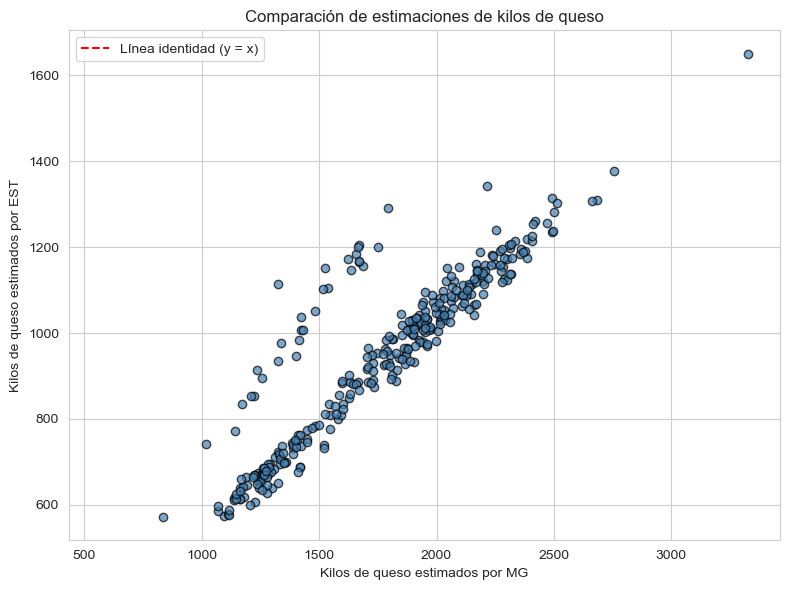

In [83]:
plt.figure(figsize=(8, 6))
plt.scatter(df['kg_queso_por_mg'], df['kg_queso_por_est'], alpha=0.7, color='steelblue', edgecolor='k')

# Línea de identidad (y = x)
min_val = min(df['kg_queso_por_mg'].min(), df['kg_queso_por_est'].min())
max_val = max(df['kg_queso_por_mg'].max(), df['kg_queso_por_est'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Línea identidad (y = x)')

# Etiquetas y título
plt.xlabel('Kilos de queso estimados por MG')
plt.ylabel('Kilos de queso estimados por EST')
plt.title('Comparación de estimaciones de kilos de queso')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [84]:
# Eliminar filas con NaN en las columnas relevantes
df_clean = df[['kg_queso_por_mg', 'kg_queso_por_est']].replace([np.inf, -np.inf], np.nan).dropna()

# Datos limpios para regresión
x = df_clean['kg_queso_por_mg']
y = df_clean['kg_queso_por_est']


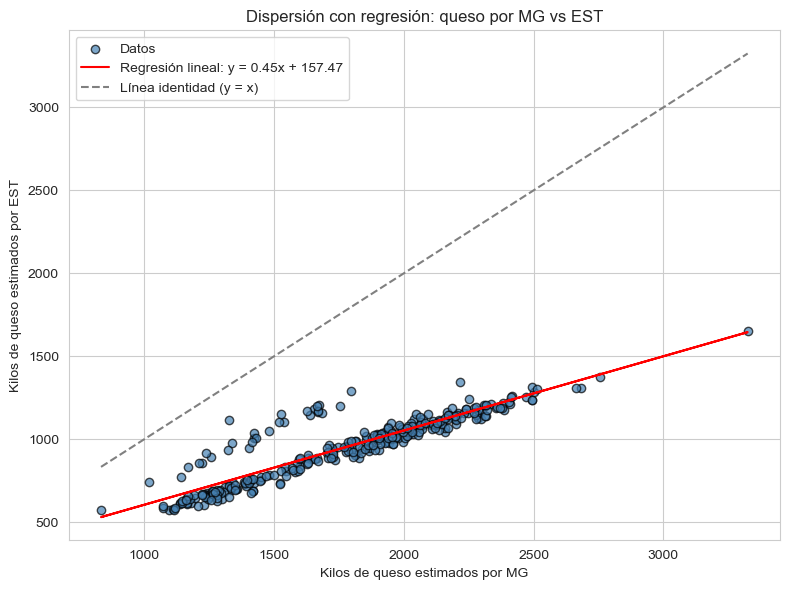

In [85]:
from sklearn.linear_model import LinearRegression

# Ajuste de regresión lineal
model = LinearRegression()
model.fit(x.values.reshape(-1, 1), y.values)
y_pred = model.predict(x.values.reshape(-1, 1))

# Coeficientes
slope = model.coef_[0]
intercept = model.intercept_

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, color='steelblue', edgecolor='k', label='Datos')
plt.plot(x, y_pred, color='red', label=f'Regresión lineal: y = {slope:.2f}x + {intercept:.2f}')
plt.plot([x.min(), x.max()], [x.min(), x.max()], color='gray', linestyle='--', label='Línea identidad (y = x)')

# Estética
plt.xlabel('Kilos de queso estimados por MG')
plt.ylabel('Kilos de queso estimados por EST')
plt.title('Dispersión con regresión: queso por MG vs EST')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

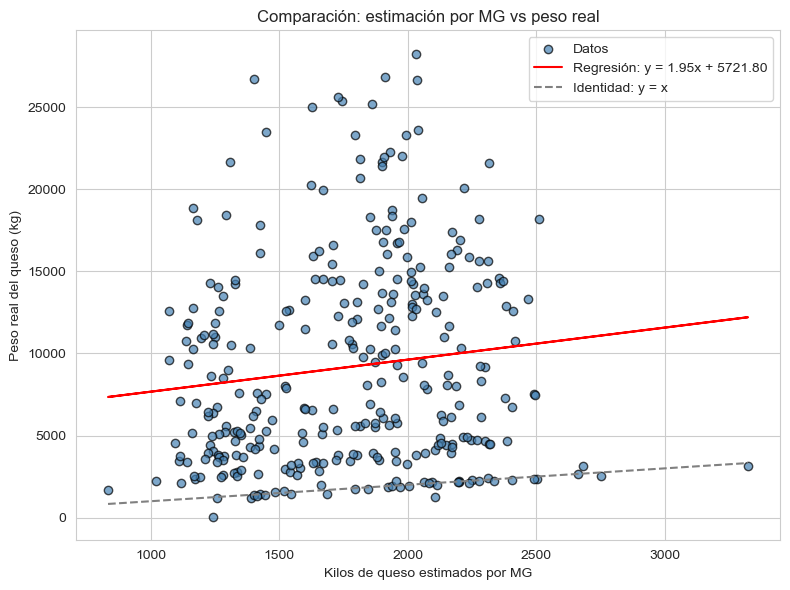

In [86]:
# Eliminar NaN e infinitos
df_clean = df[['kg_queso_por_mg', 'peso_queso_total']].replace([np.inf, -np.inf], np.nan).dropna()

# Variables
x = df_clean['kg_queso_por_mg'].values.reshape(-1, 1)
y = df_clean['peso_queso_total'].values

# Ajuste de regresión lineal
model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

# Coeficientes
slope = model.coef_[0]
intercept = model.intercept_

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, color='steelblue', edgecolor='k', label='Datos')
plt.plot(x, y_pred, color='red', label=f'Regresión: y = {slope:.2f}x + {intercept:.2f}')
plt.plot([x.min(), x.max()], [x.min(), x.max()], color='gray', linestyle='--', label='Identidad: y = x')

# Estética
plt.xlabel('Kilos de queso estimados por MG')
plt.ylabel('Peso real del queso (kg)')
plt.title('Comparación: estimación por MG vs peso real')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [87]:
df['rendimiento_simple'] = df['litros_past'] / df['peso_queso_total']
df['rendimiento_por_mg'] = df['litros_past'] / df['kg_queso_por_mg']

df_filtrado = df[(df['rendimiento_simple'] > 5) & (df['rendimiento_simple'] < 20)]


In [88]:
df_filtrado.head()

,fecha,receta,litros_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,lactosa_cuba,ph_cuajado,ph_inicio_moldeo_cuba,...,coef_recup_mp,coef_recup_mg,mp_kg_recuperado,mg_kg_recuperado,est_kg_recuperado,kg_queso_por_mg,kg_queso_por_est,kg_queso_estimado,rendimiento_simple,rendimiento_por_mg
fecha_index,,,,,,,,,,,,,,,,,,,,,
2022-02-23,2022-02-23,light 3 kg,12330,12860.51,10.28,2.46,3.38,4.44,6.60,6.50,...,0.915370,0.915077,397.897933,289.501736,512.099262,1423.312371,1007.078195,1007.078195,8.687381,8.662891
2022-02-24,2022-02-24,iqm barra 3 kg,7500,7500.00,12.80,4.90,3.89,4.01,6.61,6.44,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.059488,NaN
2022-03-01,2022-03-01,light 3 kg,13030,13867.37,10.41,2.47,3.43,4.51,6.60,6.48,...,0.914514,0.914927,434.989244,313.384444,560.072921,1481.723139,1050.399327,1050.399327,8.483073,8.793816
2022-03-01,2022-03-01,"vaca barra 4,2 kg",14820,15810.99,12.85,5.03,3.97,3.85,6.56,6.44,...,0.969468,0.967814,608.531470,769.695700,730.276093,2502.261703,1282.536166,1282.536166,6.303701,5.922642
2022-03-04,2022-03-04,"oveja normal barra 4,2 kg",11890,12344.19,14.37,5.86,4.55,3.96,6.53,6.47,...,0.977037,0.977499,548.763425,707.092854,646.529409,NaN,NaN,NaN,5.797172,NaN


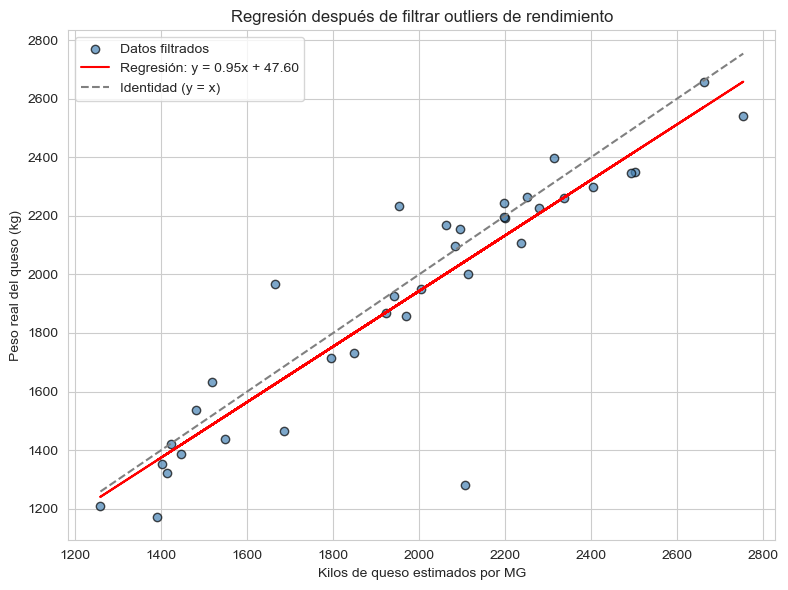

In [89]:
df_model = df_filtrado[['kg_queso_por_mg', 'peso_queso_total']].replace([np.inf, -np.inf], np.nan).dropna().copy()

x = df_model['kg_queso_por_mg'].values.reshape(-1, 1)
y = df_model['peso_queso_total'].values

model = LinearRegression()
model.fit(x, y)
y_pred = model.predict(x)

# Gráfico
plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.7, color='steelblue', edgecolor='k', label='Datos filtrados')
plt.plot(x, y_pred, color='red', label=f'Regresión: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')
plt.plot([x.min(), x.max()], [x.min(), x.max()], color='gray', linestyle='--', label='Identidad (y = x)')
plt.xlabel('Kilos de queso estimados por MG')
plt.ylabel('Peso real del queso (kg)')
plt.title('Regresión después de filtrar outliers de rendimiento')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

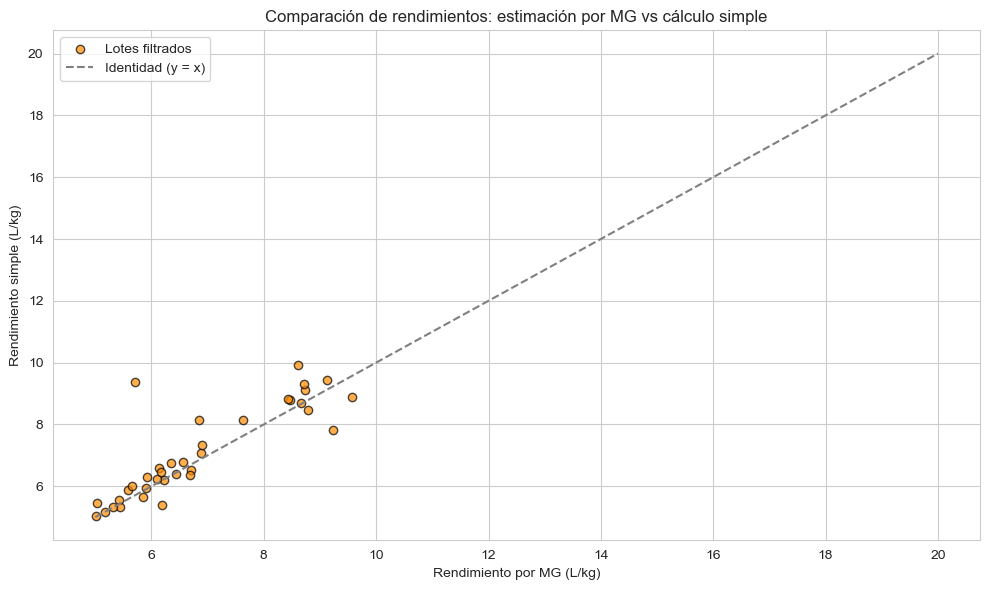

In [90]:
plt.figure(figsize=(10, 6))
plt.scatter(df_filtrado['rendimiento_por_mg'], df_filtrado['rendimiento_simple'],
            alpha=0.7, color='darkorange', edgecolor='k', label='Lotes filtrados')
plt.plot([5, 20], [5, 20], color='gray', linestyle='--', label='Identidad (y = x)')

plt.xlabel('Rendimiento por MG (L/kg)')
plt.ylabel('Rendimiento simple (L/kg)')
plt.title('Comparación de rendimientos: estimación por MG vs cálculo simple')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [91]:
df_filtrado.to_csv('datos_filtrados_rendimiento.csv', index=False, decimal = ',', sep = ';')

In [92]:
df_filtrado['receta'].value_counts()

receta
light 3 kg                     9
vaca barra 4,2 kg              9
oveja normal barra 4,2 kg      6
iqm + barra 4,2 sin lactosa    5
iqm+ 3 kg                      4
oveja do barra 4,2 kg          4
iqm + mini sin lactosa         2
madurado barra 4,2 kg          2
iqm  barra 3 kg                1
iqm sin lactosa                1
tierno barra 3 kg              1
light mini                     1
Name: count, dtype: int64

In [93]:
df_excluidos = df[~df.index.isin(df_filtrado.index)]


Hay muchos valores que no permiten calcular el rendimiento, porque faltan litros o kilos 

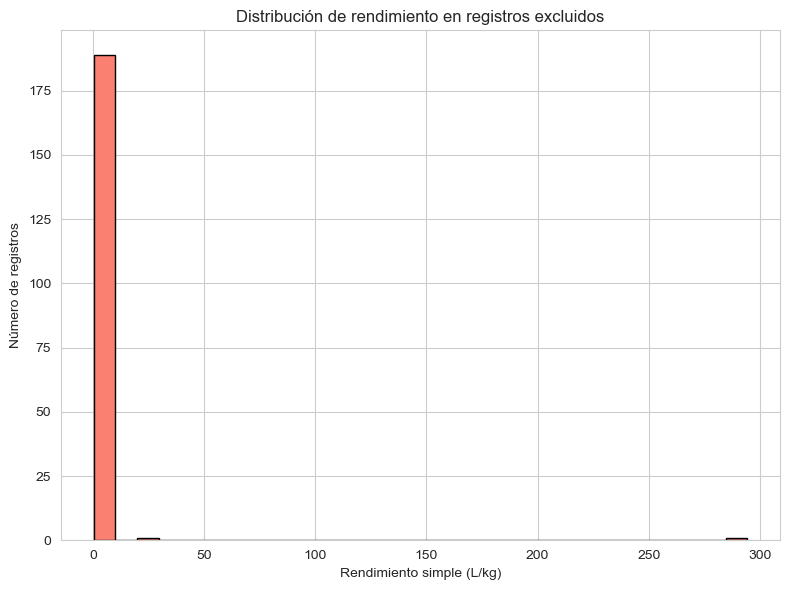

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.hist(df_excluidos['rendimiento_simple'], bins=30, color='salmon', edgecolor='k')
plt.xlabel('Rendimiento simple (L/kg)')
plt.ylabel('Número de registros')
plt.title('Distribución de rendimiento en registros excluidos')
plt.grid(True)
plt.tight_layout()
plt.show()

Buscamos diferentes problemas en los datos

In [95]:
df[df['peso_queso_total'].isna() | (df['peso_queso_total'] == 0)].shape


(0, 32)

In [96]:
df[df['litros_past'] == 0].shape


(0, 32)

In [97]:
df[df['rendimiento_simple'] == 0].shape

(0, 32)

In [98]:
df_fuera_de_rango = df[(df['rendimiento_simple'] <= 5) | (df['rendimiento_simple'] >= 20)]
print(f"Registros con rendimiento fuera de rango: {df_fuera_de_rango.shape[0]}")


Registros con rendimiento fuera de rango: 403


In [99]:
df_nan = df[df['rendimiento_simple'].isna()]
print(f"Registros con rendimiento NaN: {df_nan.shape[0]}")


Registros con rendimiento NaN: 0


In [100]:
total_excluidos = df.shape[0] - df_filtrado.shape[0]
print(f"Total de registros excluidos: {total_excluidos}")


Total de registros excluidos: 403


In [101]:
df_excluidos = df[~df.index.isin(df_filtrado.index)].copy()

# Etiquetar el tipo de error
df_excluidos['error_tipo'] = 'fuera_de_rango'
df_excluidos.loc[df_excluidos['peso_queso_total'].isna() | (df_excluidos['peso_queso_total'] == 0), 'error_tipo'] = 'peso_queso_total_cero'
df_excluidos.loc[df_excluidos['rendimiento_simple'].isna(), 'error_tipo'] = 'rendimiento_nan'


In [102]:
df_excluidos['error_tipo'] = 'fuera_de_rango'
df_excluidos.loc[df_excluidos['peso_queso_total'].isna() | (df_excluidos['peso_queso_total'] == 0), 'error_tipo'] = 'peso_queso_total_cero'
df_excluidos.loc[df_excluidos['rendimiento_simple'].isna(), 'error_tipo'] = 'rendimiento_nan'

In [103]:
df_excluidos.head()

,fecha,receta,litros_past,kg_cuba,est_cuba,mg_cuba,mp_cuba,lactosa_cuba,ph_cuajado,ph_inicio_moldeo_cuba,...,coef_recup_mg,mp_kg_recuperado,mg_kg_recuperado,est_kg_recuperado,kg_queso_por_mg,kg_queso_por_est,kg_queso_estimado,rendimiento_simple,rendimiento_por_mg,error_tipo
fecha_index,,,,,,,,,,,,,,,,,,,,,
2022-02-22,2022-02-22,iqm pequeño,9020,9404.95,13.39,5.18,4.06,4.15,6.56,6.47,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.029666,NaN,fuera_de_rango
2022-02-22,2022-02-22,oveja do 3 kg,9830,10241.07,14.92,6.19,4.88,3.85,6.60,6.50,...,0.894370,446.910185,566.961162,525.766424,1902.554235,932.871582,932.871582,1.624176,5.166738,fuera_de_rango
2022-02-22,2022-02-22,tierno 3 kg,14330,15059.58,13.03,4.84,3.78,4.41,6.59,6.38,...,0.896781,510.583602,653.648740,643.409097,2111.950694,1112.394705,1112.394705,1.143473,6.785196,fuera_de_rango
2022-02-22,2022-02-22,oveja do pequeño,6780,7506.26,14.93,6.18,4.89,3.86,6.60,6.50,...,0.900782,330.237446,417.860852,388.185773,NaN,NaN,NaN,1.527887,NaN,fuera_de_rango
2022-02-22,2022-02-22,madurado pequeño,9520,10067.49,12.50,4.60,3.62,4.28,6.57,6.41,...,0.903429,329.082349,418.382269,415.260064,1326.513218,722.568407,722.568407,0.669692,7.176709,fuera_de_rango


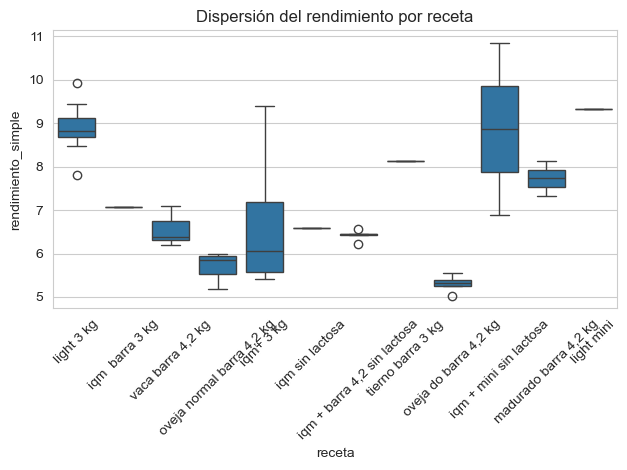

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_filtrado, x='receta', y='rendimiento_simple')
plt.xticks(rotation=45)
plt.title('Dispersión del rendimiento por receta')
plt.tight_layout()
plt.show()


In [105]:
df_filtrado['receta'].value_counts()

receta
light 3 kg                     9
vaca barra 4,2 kg              9
oveja normal barra 4,2 kg      6
iqm + barra 4,2 sin lactosa    5
iqm+ 3 kg                      4
oveja do barra 4,2 kg          4
iqm + mini sin lactosa         2
madurado barra 4,2 kg          2
iqm  barra 3 kg                1
iqm sin lactosa                1
tierno barra 3 kg              1
light mini                     1
Name: count, dtype: int64

In [106]:
df_filtrado.to_csv('datos_filtrados_rendimiento_confiable.csv', index=False, decimal = ',', sep = ';')

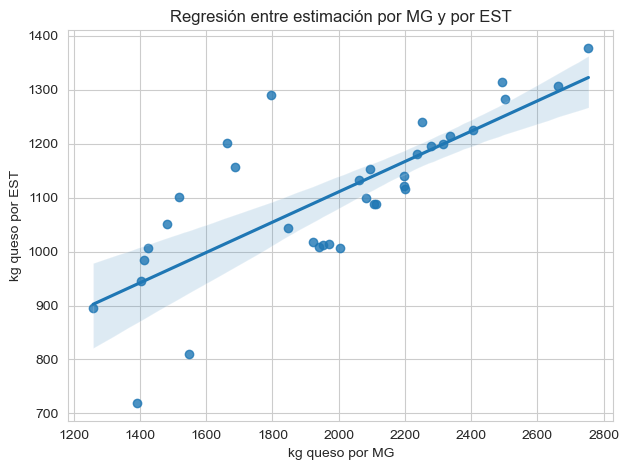

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x='kg_queso_por_mg', y='kg_queso_por_est', data=df_filtrado)
plt.title('Regresión entre estimación por MG y por EST')
plt.xlabel('kg queso por MG')
plt.ylabel('kg queso por EST')
plt.grid(True)
plt.tight_layout()
plt.show()


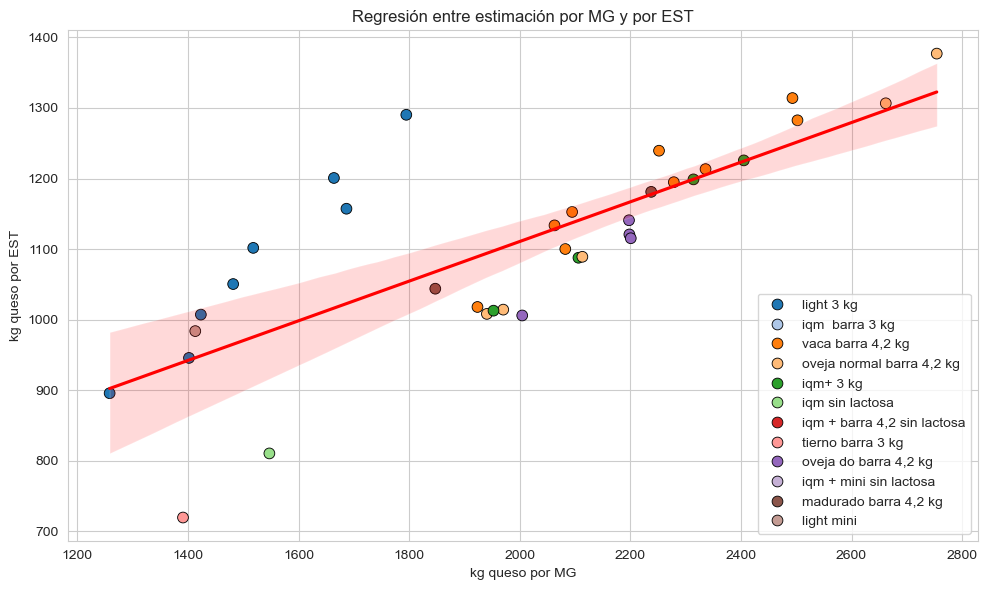

In [108]:
plt.figure(figsize=(10, 6))

df_plot = df_filtrado.reset_index(drop=True)

# Puntos coloreados por receta
sns.scatterplot(
    x='kg_queso_por_mg',
    y='kg_queso_por_est',
    hue='receta',
    data=df_plot,
    palette='tab20',  # Puedes cambiar a 'Set2', 'husl', etc.
    s=60,
    edgecolor='black'
)

# Línea de regresión general
sns.regplot(
    x='kg_queso_por_mg',
    y='kg_queso_por_est',
    data=df_plot,
    scatter=False,
    color='red',
    line_kws={"label": "Regresión global"}
)

plt.title('Regresión entre estimación por MG y por EST')
plt.xlabel('kg queso por MG')
plt.ylabel('kg queso por EST')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

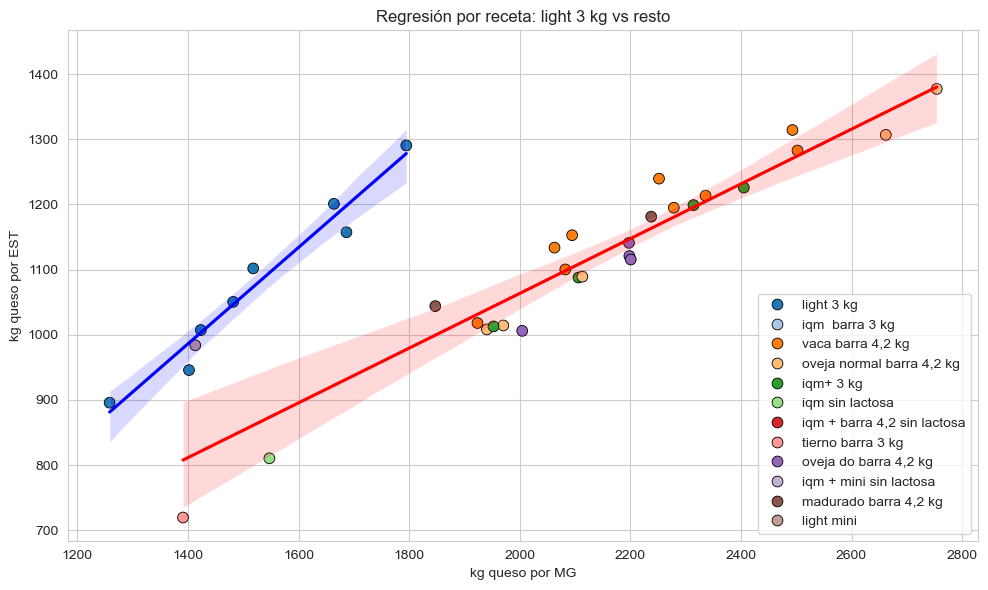

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

df_plot = df_filtrado.reset_index(drop=True)

# Separar los datos
df_light = df_plot[df_plot['receta'] == 'light 3 kg']
df_otros = df_plot[df_plot['receta'] != 'light 3 kg']

# Puntos coloreados por receta
sns.scatterplot(
    x='kg_queso_por_mg',
    y='kg_queso_por_est',
    hue='receta',
    data=df_plot,
    palette='tab20',
    s=60,
    edgecolor='black'
)

# Regresión para 'light 3 kg'
sns.regplot(
    x='kg_queso_por_mg',
    y='kg_queso_por_est',
    data=df_light,
    scatter=False,
    color='blue',
    line_kws={"label": "Regresión light 3 kg"}
)

# Regresión para el resto
sns.regplot(
    x='kg_queso_por_mg',
    y='kg_queso_por_est',
    data=df_otros,
    scatter=False,
    color='red',
    line_kws={"label": "Regresión resto"}
)

plt.title('Regresión por receta: light 3 kg vs resto')
plt.xlabel('kg queso por MG')
plt.ylabel('kg queso por EST')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()